## ECE频谱图

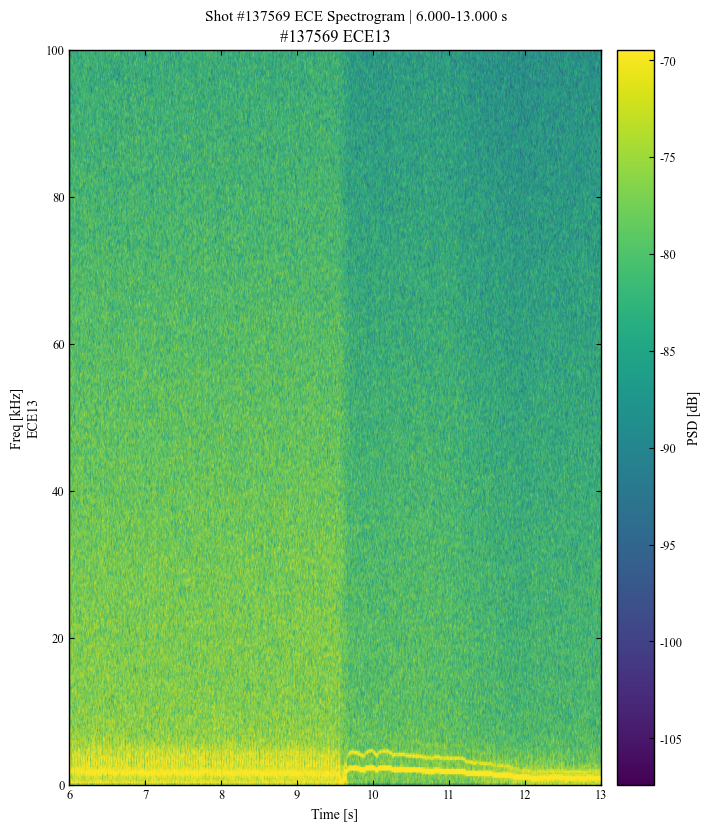

图已保存到: ece_spectrogram_137569.png


In [4]:
# -*- coding: utf-8 -*-
import numpy as np
import matplotlib.pyplot as plt

from spectrum_toolbox import ProbePlotter

# ====================== 科研绘图全局配置 ======================
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'SimSun'],
    'mathtext.fontset': 'stix',
    'axes.unicode_minus': False,
    'font.size': 10,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 8,
    'figure.titlesize': 11,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'axes.linewidth': 1.0
})

# ====================== 参数区 ======================
shot = 137569
ece_channels = [13]      # 要画哪些ECE通道；单通道就写成 [12]
time_range = (6.0, 13.0)        # 单位 s
freq_range = (0, 100)            # 单位 kHz
time_window = 0.005              # 频谱窗长，单位 s
overlap = 0.8                    # 重叠率
tree = 'east'                    # 通常 ECE 在 east tree
save_path = f'ece_spectrogram_{shot}.png'

# ====================== 工具函数 ======================
def get_ece_signal_name(ch):
    """
    根据通道号选择工具箱中的 signal_name:
    1-9   -> 'ece1-9'
    10-48 -> 'ece10-48'
    """
    if 1 <= ch <= 9:
        return 'ece1-9'
    elif 10 <= ch <= 48:
        return 'ece10-48'
    else:
        raise ValueError(f"ECE channel should be in 1~48, but got {ch}")


def compute_vrange(spec_data, low=5, high=99.5):
    """
    自动估计色标范围，避免个别极端点把动态范围拉坏
    """
    z = spec_data.data.values
    return np.percentile(z, low), np.percentile(z, high)


# ====================== 主程序 ======================
plotter = ProbePlotter()

n_ch = len(ece_channels)
fig, axes = plt.subplots(
    n_ch, 1,
    figsize=(7.0, 8.0 * n_ch),
    sharex=True,
    constrained_layout=True
)

if n_ch == 1:
    axes = [axes]

last_im = None

for i, ch in enumerate(ece_channels):
    ax = axes[i]
    signal_name = get_ece_signal_name(ch)

    # 计算该ECE通道的频谱数据
    spec_data = plotter.compute_spectrogram_data(
        shot=shot,
        probe_num=ch,
        signal_name=signal_name,
        time_range=time_range,
        time_window=time_window,
        overlap=overlap,
        tree=tree
    )

    # 自动设定颜色范围
    vmin, vmax = compute_vrange(spec_data)

    # 直接调用工具箱里的 SpectralData.plot()
    _, im = spec_data.plot(
        ax=ax,
        freq_range=freq_range,
        time_range=time_range,
        cmap='viridis',
        vmin=vmin,
        vmax=vmax
    )
    last_im = im

    ax.set_ylabel(f'Freq [kHz]\nECE{ch}')
    ax.set_title(f'#{shot} ECE{ch}')
    ax.set_ylim([0,100])

axes[-1].set_xlabel('Time [s]')

# 统一加一个 colorbar
if last_im is not None:
    cbar = fig.colorbar(last_im, ax=axes, pad=0.02)
    cbar.set_label('PSD [dB]')

fig.suptitle(
    f'Shot #{shot} ECE Spectrogram | {time_range[0]:.3f}-{time_range[1]:.3f} s',
    y=1.02
)

plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f'图已保存到: {save_path}')

## 寻找

In [ ]:
# -*- coding: utf-8 -*-
import numpy as np
import matplotlib.pyplot as plt

from spectrum_toolbox import ProbePlotter

# ====================== 科研绘图全局配置 ======================
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'SimSun'],
    'mathtext.fontset': 'stix',
    'axes.unicode_minus': False,
    'font.size': 8,
    'axes.labelsize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'figure.titlesize': 10,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'axes.linewidth': 0.8
})

# ====================== 参数区 ======================
shot = 
ece_channels = list(range(1, 49))      # 1~48道
time_range = (6.0, 13.0)              # s
freq_range = (0, 10)                  # kHz
time_window = 0.02                    # s
overlap = 0.8
tree = 'east'
save_path = f'ece_spectrogram_grid_{shot}.png'

# 8×6 排版：8行6列，共48幅
nrows, ncols = 8, 6

# ====================== 工具函数 ======================
def get_ece_signal_name(ch):
    """
    根据通道号选择工具箱中的 signal_name
    这里按你修改后的工具箱接口来写：
    1-9   -> 'ece1-9'
    10-48 -> 'ece10-48'
    """
    if 1 <= ch <= 9:
        return 'ece1-9'
    elif 10 <= ch <= 48:
        return 'ece10-48'
    else:
        raise ValueError(f"ECE channel should be in 1~48, but got {ch}")


def compute_global_vrange(spec_data_list, low=5, high=99.5):
    """
    对所有通道统一估计色标范围，便于跨通道比较
    """
    all_values = []
    for spec_data in spec_data_list:
        if spec_data is None:
            continue
        all_values.append(spec_data.data.values.ravel())

    all_values = np.concatenate(all_values)
    vmin = np.percentile(all_values, low)
    vmax = np.percentile(all_values, high)
    return vmin, vmax


# ====================== 主程序 ======================
plotter = ProbePlotter()

# ---------- 第一步：先把48个通道的频谱都算出来 ----------
spec_data_list = []
valid_channels = []

for ch in ece_channels:
    signal_name = get_ece_signal_name(ch)
    try:
        spec_data = plotter.compute_spectrogram_data(
            shot=shot,
            probe_num=ch,
            signal_name=signal_name,
            time_range=time_range,
            time_window=time_window,
            overlap=overlap,
            tree=tree
        )
        spec_data_list.append(spec_data)
        valid_channels.append(ch)
        print(f"ECE{ch:02d} done")
    except Exception as e:
        print(f"ECE{ch:02d} failed: {e}")
        spec_data_list.append(None)
        valid_channels.append(ch)

# ---------- 第二步：统一色标 ----------
vmin, vmax = compute_global_vrange(
    [sd for sd in spec_data_list if sd is not None],
    low=5,
    high=99.5
)

# ---------- 第三步：8×6 排版绘图 ----------
fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(15, 16),
    sharex=True,
    sharey=True,
    constrained_layout=True
)

axes = axes.flatten()
last_im = None

for i, ch in enumerate(ece_channels):
    ax = axes[i]
    spec_data = spec_data_list[i]

    if spec_data is None:
        ax.text(0.5, 0.5, f'ECE{ch}\nError',
                transform=ax.transAxes,
                ha='center', va='center', fontsize=8)
        ax.set_xticks([])
        ax.set_yticks([])
        continue

    _, im = spec_data.plot(
        ax=ax,
        freq_range=freq_range,
        time_range=time_range,
        cmap='plasma',
        vmin=vmin,
        vmax=vmax
    )
    last_im = im

    # 小标题只写通道号，避免太挤
    ax.set_title(f'ECE{ch}', pad=2, fontsize=8)

    # 去掉工具箱plot默认加的长ylabel/xlabel，改成更简洁形式
    ax.set_xlabel('')
    ax.set_ylabel('')

    # 手动限制频率范围
    ax.set_ylim(freq_range)

# ---------- 第四步：只保留外侧坐标 ----------
for i, ax in enumerate(axes):
    row = i // ncols
    col = i % ncols

    if row != nrows - 1:
        ax.set_xticklabels([])
    else:
        ax.set_xlabel('Time [s]', fontsize=8)

    if col != 0:
        ax.set_yticklabels([])
    else:
        ax.set_ylabel('Freq [kHz]', fontsize=8)

# ---------- 第五步：统一 colorbar ----------
if last_im is not None:
    cbar = fig.colorbar(last_im, ax=axes.tolist(), pad=0.01, shrink=0.98)
    cbar.set_label('PSD [dB]', fontsize=9)

fig.suptitle(
    f'Shot #{shot} ECE Spectrograms ({time_range[0]:.3f}-{time_range[1]:.3f} s)',
    fontsize=12
)

plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f'图已保存到: {save_path}')

ECE01 done
ECE02 done
ECE03 done
ECE04 done
ECE05 done
ECE06 done
ECE07 done
ECE08 done
ECE09 done
ECE10 done
ECE11 done
ECE12 done
ECE13 done
ECE14 done
ECE15 done
ECE16 done
ECE17 done
ECE18 done
ECE19 done
ECE20 done
ECE21 done
ECE22 done
ECE23 done
ECE24 done
ECE25 done
ECE26 done
ECE27 done
ECE28 done
ECE29 done
ECE30 done
ECE31 done
ECE32 done
ECE33 done
ECE34 done
ECE35 done
ECE36 done
ECE37 done
ECE38 done
ECE39 done
ECE40 done
ECE41 done
ECE42 done
ECE43 done
ECE44 done
ECE45 done
ECE46 done
ECE47 done
ECE48 done


MemoryError: Unable to allocate 6.25 GiB for an array with shape (838336512,) and data type float64